# Task 4: CNN (U-Net) for LULC Prediction from Landsat Bands

**Goal:** Train a U-Net to predict ESRI LULC classes from Landsat spectral bands + NDVI  
**Patches:** 32×32 with stride 8  
**Ground Truth:** ESRI 10m LULC (resampled to 30m Landsat grid)

## 1. Install & Imports

In [ ]:
# !pip install torch torchvision rasterio numpy matplotlib scikit-learn tqdm

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [12]:
import os
# Quick search for the Landsat files
for root, dirs, files in os.walk('/teamspace'):
    for f in files:
        if 'SR_B4' in f:
            print(f"FOUND: {os.path.join(root, f)}")
            break
    else:
        continue
    break
else:
    print("Not found in /teamspace. Checking home...")
    for root, dirs, files in os.walk(os.path.expanduser('~')):
        for f in files:
            if 'SR_B4' in f:
                print(f"FOUND: {os.path.join(root, f)}")
                break
        else:
            continue
        break
    else:
        print("Files not found anywhere. Upload landsat_downloads/ folder first.")


FOUND: /teamspace/studios/this_studio/Antigravity/landsat_downloads/extracted/LC08_L2SP_201032_20260331_20260407_02_T1_SR_B4.TIF


## 2. Configuration

**Update `BASE_DIR` below if running on Lightning AI or another machine.**

In [13]:
# ======== UPDATE THIS PATH FOR YOUR ENVIRONMENT ========
# Local Windows:
# BASE_DIR = r"D:\Antigravity\landsat_downloads"
# Lightning AI (uncomment and set):
BASE_DIR = "/teamspace/studios/this_studio/Antigravity/landsat_downloads"
# ========================================================

EXTRACT_DIR = os.path.join(BASE_DIR, "extracted")
OUTPUT_DIR = BASE_DIR
LULC_FILE = os.path.join(OUTPUT_DIR, "esri_lulc_clipped.tif")

print(f"Base dir: {BASE_DIR}")
print(f"Exists: {os.path.exists(BASE_DIR)}")
if os.path.exists(EXTRACT_DIR):
    print(f"Extracted files: {len(list(Path(EXTRACT_DIR).glob('*.TIF')))}")

Base dir: /teamspace/studios/this_studio/Antigravity/landsat_downloads
Exists: True
Extracted files: 19


## 3. Load Landsat Bands & LULC

In [14]:
# Auto-detect band files (case-insensitive for cross-platform)
tif_files = list(Path(EXTRACT_DIR).glob("*.[Tt][Ii][Ff]"))
if not tif_files:
    tif_files = list(Path(EXTRACT_DIR).glob("*.tif")) + list(Path(EXTRACT_DIR).glob("*.TIF"))

band_paths = {}
for f in tif_files:
    name = f.name.upper()
    for b in ['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']:
        if b in name:
            band_paths[b] = str(f)

print("Landsat bands found:")
for b, p in sorted(band_paths.items()):
    print(f"  {b}: {os.path.basename(p)}")

assert len(band_paths) == 6, f"Expected 6 bands, found {len(band_paths)}. Check EXTRACT_DIR: {EXTRACT_DIR}"

# Read all bands and stack
band_list = ['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']
bands_data = []
for b in band_list:
    with rasterio.open(band_paths[b]) as src:
        data = src.read(1).astype(np.float32)
        if b == 'SR_B2':
            landsat_profile = src.profile.copy()
            landsat_transform = src.transform
            landsat_crs = src.crs
            landsat_bounds = src.bounds
            H, W = data.shape
        bands_data.append(data)

# Apply scale factor: SR = DN * 0.0000275 - 0.2, clip to [0,1]
for i in range(len(bands_data)):
    bands_data[i] = np.clip(bands_data[i] * 0.0000275 - 0.2, 0, 1)

# Compute NDVI = (B5 - B4) / (B5 + B4)
nir = bands_data[3]  # SR_B5
red = bands_data[2]  # SR_B4
denom = nir + red
ndvi = np.where(denom > 0, (nir - red) / denom, 0).astype(np.float32)
ndvi = np.clip(ndvi, -1, 1)

# Stack: 7 channels (B2,B3,B4,B5,B6,B7,NDVI)
image_stack = np.stack(bands_data + [ndvi], axis=0)  # (7, H, W)
del bands_data, nir, red, denom, ndvi  # free memory

print(f"\nImage stack: {image_stack.shape} (channels, H, W)")
print(f"Landsat size: {H} x {W}")
print(f"Memory: {image_stack.nbytes / 1024**2:.0f} MB")

Landsat bands found:
  SR_B2: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B2.TIF
  SR_B3: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B3.TIF
  SR_B4: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B4.TIF
  SR_B5: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B5.TIF
  SR_B6: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B6.TIF
  SR_B7: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B7.TIF

Image stack: (7, 7911, 7791) (channels, H, W)
Landsat size: 7911 x 7791
Memory: 1646 MB


In [15]:
# Load LULC and resample to match Landsat 30m grid
with rasterio.open(LULC_FILE) as src:
    lulc_10m = src.read(1)
    lulc_profile = src.profile
    lulc_transform = src.transform
    lulc_crs = src.crs
    print(f"LULC 10m shape: {lulc_10m.shape}")

# Resample LULC from 10m to 30m to match Landsat pixel grid
lulc_30m = np.zeros((H, W), dtype=np.uint8)

reproject(
    source=lulc_10m,
    destination=lulc_30m,
    src_transform=lulc_transform,
    src_crs=lulc_crs,
    dst_transform=landsat_transform,
    dst_crs=landsat_crs,
    resampling=Resampling.nearest
)

del lulc_10m  # free memory
print(f"LULC resampled to 30m: {lulc_30m.shape}")
print(f"Unique classes: {np.unique(lulc_30m)}")

LULC 10m shape: (15536, 23373)
LULC resampled to 30m: (7911, 7791)
Unique classes: [ 0  1  2  4  5  7  8  9 10 11]


In [16]:
# Remap LULC classes to contiguous indices (0..N)
raw_classes = sorted(np.unique(lulc_30m))

LULC_INFO = {
    0: ("No Data",           "#000000"),
    1: ("Water",             "#419BDF"),
    2: ("Trees",             "#397D49"),
    4: ("Flooded Veg.",     "#7A87C6"),
    5: ("Crops",             "#E49635"),
    7: ("Built Area",        "#C4281B"),
    8: ("Bare Ground",       "#A59B8F"),
    9: ("Snow/Ice",          "#B39FE1"),
    10: ("Clouds",           "#FFFFFF"),
    11: ("Rangeland",        "#A8D99C"),
}

# Remove NoData (0) from training classes
train_classes = [c for c in raw_classes if c != 0]
class_to_idx = {c: i for i, c in enumerate(train_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
num_classes = len(train_classes)

print(f"Training classes ({num_classes}):")
for c in train_classes:
    print(f"  {c:2d} -> idx {class_to_idx[c]} : {LULC_INFO.get(c, ('Unknown','#888'))[0]}")

# Create remapped label array (uint8 to save memory)
lulc_remapped = np.full_like(lulc_30m, fill_value=255, dtype=np.uint8)  # 255 = ignore
for c, idx in class_to_idx.items():
    lulc_remapped[lulc_30m == c] = idx

del lulc_30m  # free memory
print(f"\nRemapped unique: {np.unique(lulc_remapped)}")

Training classes (9):
   1 -> idx 0 : Water
   2 -> idx 1 : Trees
   4 -> idx 2 : Flooded Veg.
   5 -> idx 3 : Crops
   7 -> idx 4 : Built Area
   8 -> idx 5 : Bare Ground
   9 -> idx 6 : Snow/Ice
  10 -> idx 7 : Clouds
  11 -> idx 8 : Rangeland

Remapped unique: [  0   1   2   3   4   5   6   7   8 255]


## 4. Compute Valid Patch Coordinates (memory-efficient)

Instead of pre-extracting 400K+ patches into RAM (~15 GB), we only store the
patch **coordinates** and extract patches on-the-fly in the Dataset.

In [17]:
PATCH_SIZE = 32
STRIDE = 8

# Pre-compute which patches are valid (< 20% nodata)
valid_coords = []

for r in tqdm(range(0, H - PATCH_SIZE + 1, STRIDE), desc="Scanning rows"):
    for c in range(0, W - PATCH_SIZE + 1, STRIDE):
        label_patch = lulc_remapped[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        
        # Skip patches with >20% nodata/ignore pixels
        if np.mean(label_patch == 255) > 0.2:
            continue
        # Skip patches where image has >20% zeros
        img_patch_band0 = image_stack[0, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        if np.mean(img_patch_band0 == 0) > 0.2:
            continue
        
        valid_coords.append((r, c))

valid_coords = np.array(valid_coords, dtype=np.int32)
print(f"\nTotal valid patches: {len(valid_coords)}")
print(f"Coords memory: {valid_coords.nbytes / 1024**2:.1f} MB (vs ~15 GB if pre-extracted)")

Scanning rows: 100%|██████████| 985/985 [00:07<00:00, 139.38it/s]


Total valid patches: 432233
Coords memory: 3.3 MB (vs ~15 GB if pre-extracted)


## 5. Train / Validation / Test Split & Visualization

In [18]:
# Split: 70% train, 15% val, 15% test
indices = np.arange(len(valid_coords))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_coords = valid_coords[train_idx]
val_coords = valid_coords[val_idx]
test_coords = valid_coords[test_idx]

print(f"Train: {len(train_coords)}  Val: {len(val_coords)}  Test: {len(test_coords)}")

Train: 302563  Val: 64835  Test: 64835


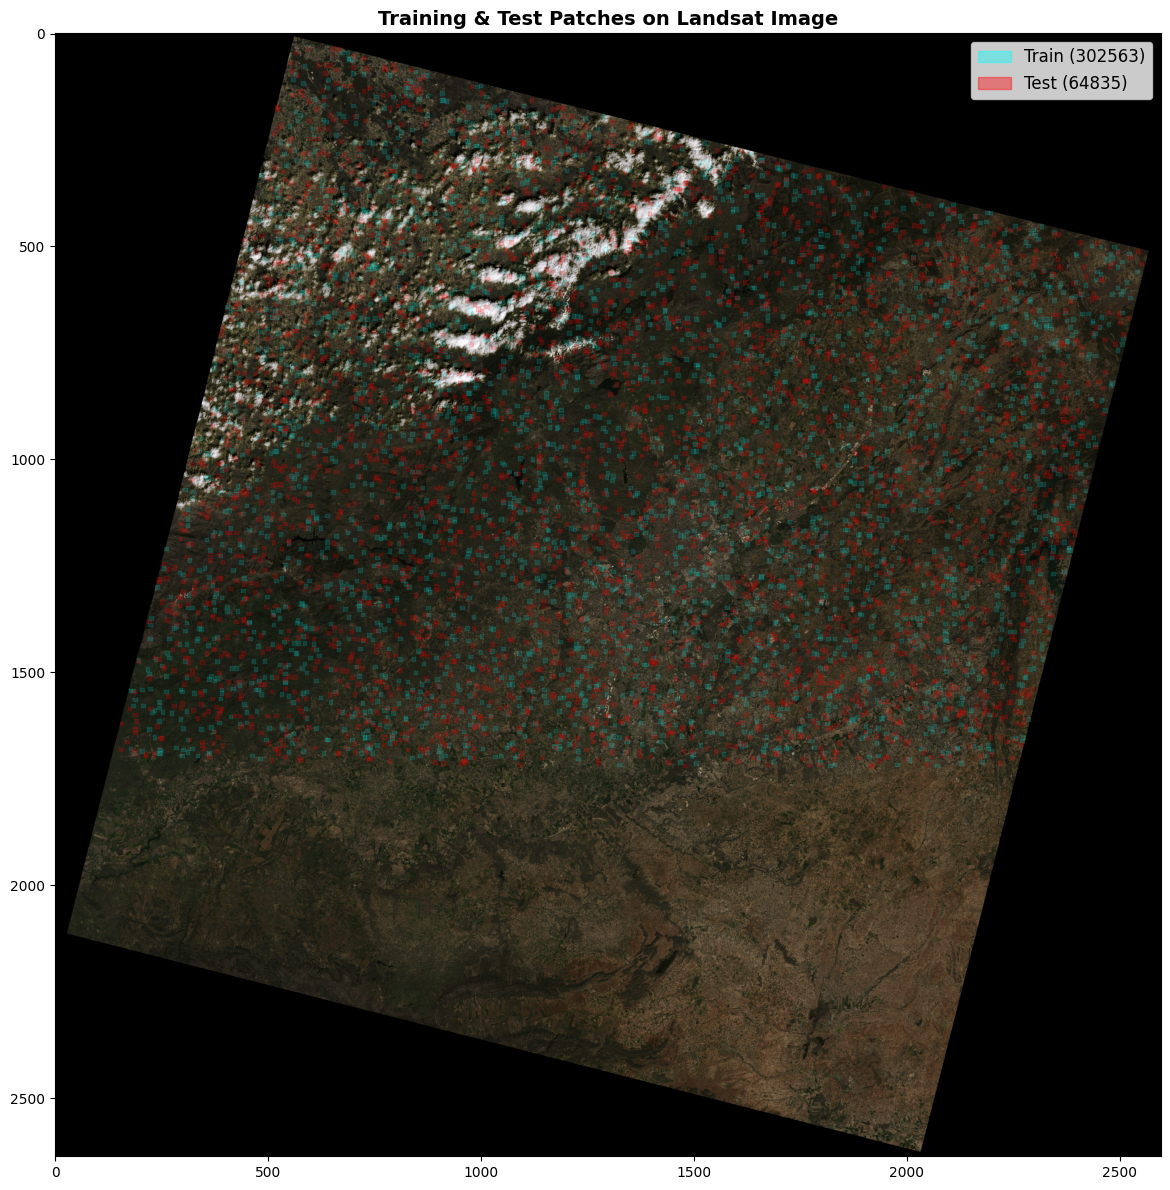

In [19]:
# (a) Display training and test patches overlaid on Landsat image
scale = max(1, max(H, W) // 2000)

# RGB composite for background
rgb_bg = np.dstack([image_stack[2], image_stack[1], image_stack[0]])  # R,G,B = B4,B3,B2
rgb_bg = np.clip(np.power(rgb_bg, 1/1.4), 0, 1)
rgb_small = rgb_bg[::scale, ::scale]
del rgb_bg

fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(rgb_small)

# Draw patch rectangles (subsample for speed)
max_show = 3000
step_tr = max(1, len(train_coords) // max_show)
step_te = max(1, len(test_coords) // max_show)

for r, c in train_coords[::step_tr]:
    rect = plt.Rectangle((c/scale, r/scale), PATCH_SIZE/scale, PATCH_SIZE/scale,
                         linewidth=0.3, edgecolor='cyan', facecolor='cyan', alpha=0.15)
    ax.add_patch(rect)

for r, c in test_coords[::step_te]:
    rect = plt.Rectangle((c/scale, r/scale), PATCH_SIZE/scale, PATCH_SIZE/scale,
                         linewidth=0.3, edgecolor='red', facecolor='red', alpha=0.2)
    ax.add_patch(rect)

legend = [
    mpatches.Patch(color='cyan', alpha=0.4, label=f'Train ({len(train_coords)})'),
    mpatches.Patch(color='red', alpha=0.4, label=f'Test ({len(test_coords)})')
]
ax.legend(handles=legend, loc='upper right', fontsize=12)
ax.set_title('Training & Test Patches on Landsat Image', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'train_test_patches.png'), dpi=100, bbox_inches='tight')
plt.show()

## 6. Lazy PyTorch Dataset (memory-efficient)

In [20]:
class LazyPatchDataset(Dataset):
    """Extracts patches on-the-fly from the full image/label arrays.
    Only stores coordinates in memory — NOT the actual patches."""
    
    def __init__(self, image_stack, label_array, coords, patch_size=32):
        self.image = image_stack    # (C, H, W) shared reference, not a copy
        self.labels = label_array   # (H, W) shared reference
        self.coords = coords        # (N, 2) only this is per-dataset
        self.ps = patch_size
    
    def __len__(self):
        return len(self.coords)
    
    def __getitem__(self, idx):
        r, c = self.coords[idx]
        x = self.image[:, r:r+self.ps, c:c+self.ps].copy()  # (C, 32, 32)
        y = self.labels[r:r+self.ps, c:c+self.ps].copy()    # (32, 32)
        return torch.from_numpy(x), torch.from_numpy(y).long()


train_ds = LazyPatchDataset(image_stack, lulc_remapped, train_coords, PATCH_SIZE)
val_ds = LazyPatchDataset(image_stack, lulc_remapped, val_coords, PATCH_SIZE)
test_ds = LazyPatchDataset(image_stack, lulc_remapped, test_coords, PATCH_SIZE)

# Quick sanity check
x_sample, y_sample = train_ds[0]
print(f"Datasets: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
print(f"Sample shapes: x={x_sample.shape}, y={y_sample.shape}")
print(f"Memory used by dataset: ~{valid_coords.nbytes / 1024**2:.1f} MB (coords only)")

Datasets: train=302563, val=64835, test=64835
Sample shapes: x=torch.Size([7, 32, 32]), y=torch.Size([32, 32])
Memory used by dataset: ~3.3 MB (coords only)


## 7. U-Net Architecture

In [21]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """U-Net for semantic segmentation of 32x32 patches."""
    def __init__(self, in_channels=7, num_classes=9, base_filters=64):
        super().__init__()
        f = base_filters
        
        # Encoder
        self.enc1 = ConvBlock(in_channels, f)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(f, f*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(f*2, f*4)
        self.pool3 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = ConvBlock(f*4, f*8)
        
        # Decoder
        self.up3 = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
        self.dec3 = ConvBlock(f*8, f*4)
        self.up2 = nn.ConvTranspose2d(f*4, f*2, 2, stride=2)
        self.dec2 = ConvBlock(f*4, f*2)
        self.up1 = nn.ConvTranspose2d(f*2, f, 2, stride=2)
        self.dec1 = ConvBlock(f*2, f)
        
        # Output
        self.out_conv = nn.Conv2d(f, num_classes, 1)
    
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                     # (B, f, 32, 32)
        e2 = self.enc2(self.pool1(e1))        # (B, 2f, 16, 16)
        e3 = self.enc3(self.pool2(e2))        # (B, 4f, 8, 8)
        
        # Bottleneck
        b = self.bottleneck(self.pool3(e3))    # (B, 8f, 4, 4)
        
        # Decoder with skip connections
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        
        return self.out_conv(d1)  # (B, num_classes, 32, 32)


model = UNet(in_channels=7, num_classes=num_classes, base_filters=64).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net created: {total_params:,} parameters")
print(f"  Input : 7 channels (B2-B7 + NDVI)")
print(f"  Output: {num_classes} LULC classes")
print(model)

U-Net created: 7,705,801 parameters
  Input : 7 channels (B2-B7 + NDVI)
  Output: 9 LULC classes
UNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(7, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-

## 8. Training Loop

In [22]:
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=1e-4):
    """Train U-Net and return history."""
    criterion = nn.CrossEntropyLoss(ignore_index=255)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss = 0
        n_train = 0
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            n_train += X_batch.size(0)
        train_loss /= n_train
        
        # --- Validate ---
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        n_val = 0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, Y_batch)
                val_loss += loss.item() * X_batch.size(0)
                n_val += X_batch.size(0)
                
                pred_cls = pred.argmax(dim=1)
                mask = Y_batch != 255
                correct += (pred_cls[mask] == Y_batch[mask]).sum().item()
                total += mask.sum().item()
        
        val_loss /= n_val
        val_acc = correct / max(total, 1)
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_unet.pth'))
        
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val Acc: {val_acc:.4f}")
    
    return history

In [23]:
# Initial training run
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-3

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(device.type=='cuda'))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=(device.type=='cuda'))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=(device.type=='cuda'))

print(f"Training: epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}")
print(f"Batches per epoch: train={len(train_loader)}, val={len(val_loader)}\n")

history = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Training: epochs=25, batch=32, lr=0.001
Batches per epoch: train=9456, val=2027

  Epoch   1/25 | Train Loss: 0.5265 | Val Loss: 0.5612 | Val Acc: 0.7723
  Epoch   2/25 | Train Loss: 0.4375 | Val Loss: 0.4331 | Val Acc: 0.8189
  Epoch   4/25 | Train Loss: 0.4024 | Val Loss: 0.5401 | Val Acc: 0.7832
  Epoch   6/25 | Train Loss: 0.3838 | Val Loss: 0.4411 | Val Acc: 0.8184
  Epoch   8/25 | Train Loss: 0.3701 | Val Loss: 0.3578 | Val Acc: 0.8554
  Epoch  10/25 | Train Loss: 0.3635 | Val Loss: 0.3527 | Val Acc: 0.8594
  Epoch  12/25 | Train Loss: 0.3565 | Val Loss: 0.3962 | Val Acc: 0.8382
  Epoch  14/25 | Train Loss: 0.3519 | Val Loss: 0.3533 | Val Acc: 0.8574
  Epoch  16/25 | Train Loss: 0.3142 | Val Loss: 0.3118 | Val Acc: 0.8769
  Epoch  18/25 | Train Loss: 0.3039 | Val Loss: 0.3072 | Val Acc: 0.8782
  Epoch  20/25 | Train Loss: 0.3002 | Val Loss: 0.3015 | Val Acc: 0.8811
  Epoch  22/25 | Train Loss: 0.2970 | Val Loss: 0.2976 | Val Acc: 0.8831
  Epoch  24/25 | Train Loss: 0.2950 | Val L

In [24]:
new_history = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=3e-4)

  Epoch   1/25 | Train Loss: 0.2744 | Val Loss: 0.2696 | Val Acc: 0.8948
  Epoch   2/25 | Train Loss: 0.2703 | Val Loss: 0.2737 | Val Acc: 0.8928
  Epoch   4/25 | Train Loss: 0.2683 | Val Loss: 0.2682 | Val Acc: 0.8947
  Epoch   6/25 | Train Loss: 0.2668 | Val Loss: 0.2715 | Val Acc: 0.8939
  Epoch   8/25 | Train Loss: 0.2659 | Val Loss: 0.2662 | Val Acc: 0.8960
  Epoch  10/25 | Train Loss: 0.2483 | Val Loss: 0.2469 | Val Acc: 0.9035
  Epoch  12/25 | Train Loss: 0.2436 | Val Loss: 0.2562 | Val Acc: 0.9003
  Epoch  14/25 | Train Loss: 0.2423 | Val Loss: 0.2414 | Val Acc: 0.9060
  Epoch  16/25 | Train Loss: 0.2412 | Val Loss: 0.2447 | Val Acc: 0.9046
  Epoch  18/25 | Train Loss: 0.2406 | Val Loss: 0.2431 | Val Acc: 0.9051
  Epoch  20/25 | Train Loss: 0.2289 | Val Loss: 0.2343 | Val Acc: 0.9084
  Epoch  22/25 | Train Loss: 0.2279 | Val Loss: 0.2299 | Val Acc: 0.9104
  Epoch  24/25 | Train Loss: 0.2267 | Val Loss: 0.2304 | Val Acc: 0.9100


In [25]:
# A more automated way to merge everything regardless of the key name
for key in history.keys():
    if key in new_history:
        history[key].extend(new_history[key])

In [26]:
new_history_1 = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=3e-5)

  Epoch   1/25 | Train Loss: 0.2204 | Val Loss: 0.2315 | Val Acc: 0.9099
  Epoch   2/25 | Train Loss: 0.2193 | Val Loss: 0.2252 | Val Acc: 0.9121
  Epoch   4/25 | Train Loss: 0.2184 | Val Loss: 0.2237 | Val Acc: 0.9126
  Epoch   6/25 | Train Loss: 0.2181 | Val Loss: 0.2223 | Val Acc: 0.9132
  Epoch   8/25 | Train Loss: 0.2176 | Val Loss: 0.2269 | Val Acc: 0.9113
  Epoch  10/25 | Train Loss: 0.2172 | Val Loss: 0.2229 | Val Acc: 0.9130
  Epoch  12/25 | Train Loss: 0.2145 | Val Loss: 0.2207 | Val Acc: 0.9138
  Epoch  14/25 | Train Loss: 0.2141 | Val Loss: 0.2260 | Val Acc: 0.9119
  Epoch  16/25 | Train Loss: 0.2139 | Val Loss: 0.2200 | Val Acc: 0.9141
  Epoch  18/25 | Train Loss: 0.2136 | Val Loss: 0.2184 | Val Acc: 0.9147
  Epoch  20/25 | Train Loss: 0.2135 | Val Loss: 0.2188 | Val Acc: 0.9145
  Epoch  22/25 | Train Loss: 0.2134 | Val Loss: 0.2196 | Val Acc: 0.9142
  Epoch  24/25 | Train Loss: 0.2116 | Val Loss: 0.2176 | Val Acc: 0.9150


In [27]:
for key in history.keys():
    if key in new_history_1:
        history[key].extend(new_history_1[key])

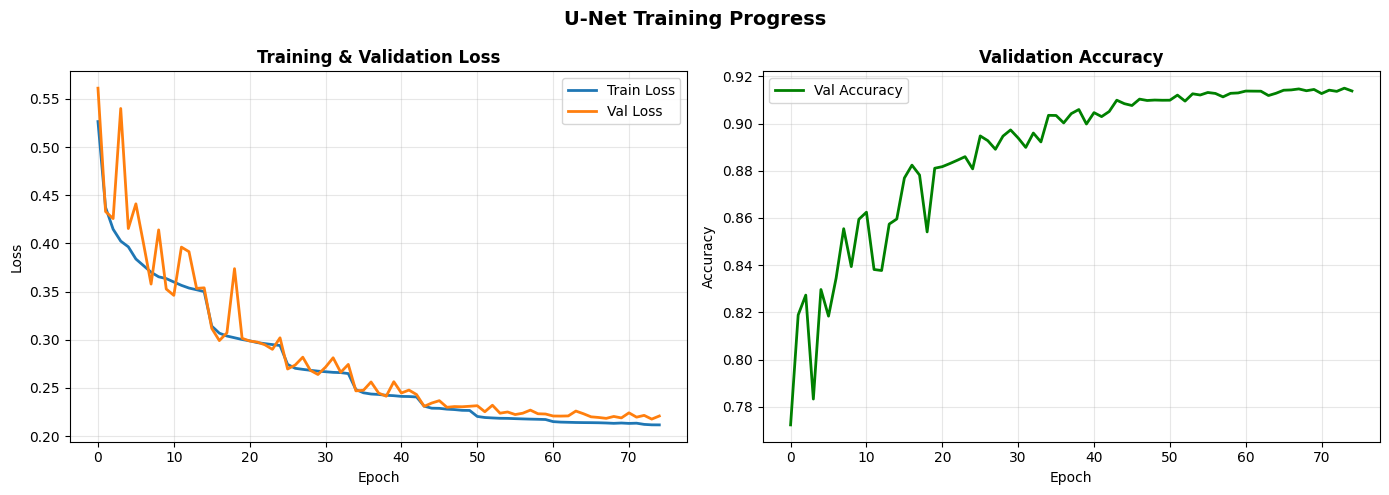

In [30]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['val_acc'], label='Val Accuracy', linewidth=2, color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('U-Net Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 9. (b) Hyperparameter Tuning on Validation Set

In [33]:
# Hyperparameter grid search
hp_configs = [
    {'lr': 1e-3, 'batch_size': 16, 'weight_decay': 1e-4, 'base_filters': 32},
    {'lr': 5e-4, 'batch_size': 32, 'weight_decay': 1e-4, 'base_filters': 64},
    {'lr': 1e-3, 'batch_size': 32, 'weight_decay': 1e-5, 'base_filters': 64},
    {'lr': 5e-4, 'batch_size': 64, 'weight_decay': 1e-3, 'base_filters': 32},
]

HP_EPOCHS = 10  # Quick runs for tuning
hp_results = []

for i, cfg in enumerate(hp_configs):
    print(f"\n{'='*50}")
    print(f"Config {i+1}/{len(hp_configs)}: lr={cfg['lr']}, bs={cfg['batch_size']}, "
          f"wd={cfg['weight_decay']}, filters={cfg['base_filters']}")
    print('='*50)
    
    # Create fresh model
    m = UNet(in_channels=7, num_classes=num_classes,
             base_filters=cfg['base_filters']).to(device)
    
    tl = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True, num_workers=0)
    vl = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=0)
    
    h = train_model(m, tl, vl, epochs=HP_EPOCHS,
                    lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    
    best_val_acc = max(h['val_acc'])
    best_val_loss = min(h['val_loss'])
    
    hp_results.append({
        **cfg,
        'best_val_acc': best_val_acc,
        'best_val_loss': best_val_loss,
        'history': h
    })
    print(f"  >> Best Val Acc: {best_val_acc:.4f}, Best Val Loss: {best_val_loss:.4f}")
    
    del m  # free GPU memory
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


Config 1/4: lr=0.001, bs=16, wd=0.0001, filters=32
  Epoch   1/10 | Train Loss: 0.5689 | Val Loss: 0.5002 | Val Acc: 0.7899
  Epoch   2/10 | Train Loss: 0.4774 | Val Loss: 0.7551 | Val Acc: 0.6851
  Epoch   4/10 | Train Loss: 0.4460 | Val Loss: 0.4257 | Val Acc: 0.8226
  Epoch   6/10 | Train Loss: 0.4334 | Val Loss: 0.5033 | Val Acc: 0.7931
  Epoch   8/10 | Train Loss: 0.4267 | Val Loss: 0.4131 | Val Acc: 0.8336
  Epoch  10/10 | Train Loss: 0.4188 | Val Loss: 0.4089 | Val Acc: 0.8338
  >> Best Val Acc: 0.8386, Best Val Loss: 0.3987

Config 2/4: lr=0.0005, bs=32, wd=0.0001, filters=64
  Epoch   1/10 | Train Loss: 0.5201 | Val Loss: 0.5593 | Val Acc: 0.7810
  Epoch   2/10 | Train Loss: 0.4203 | Val Loss: 0.4223 | Val Acc: 0.8251
  Epoch   4/10 | Train Loss: 0.3711 | Val Loss: 0.3836 | Val Acc: 0.8470
  Epoch   6/10 | Train Loss: 0.3392 | Val Loss: 0.3328 | Val Acc: 0.8671
  Epoch   8/10 | Train Loss: 0.3178 | Val Loss: 0.3278 | Val Acc: 0.8699
  Epoch  10/10 | Train Loss: 0.3052 | Val L


HYPERPARAMETER TUNING RESULTS
  Config       LR   BS       WD  Filters  Val Acc  Val Loss
----------------------------------------------------------------------
       1    1e-03   16    1e-04       32   0.8386    0.3987
       2    5e-04   32    1e-04       64   0.8770    0.3109
       3    1e-03   32    1e-05       64   0.8873    0.2849 <<< BEST
       4    5e-04   64    1e-03       32   0.8684    0.3347

Best config: lr=0.001, bs=32, wd=1e-05, filters=64


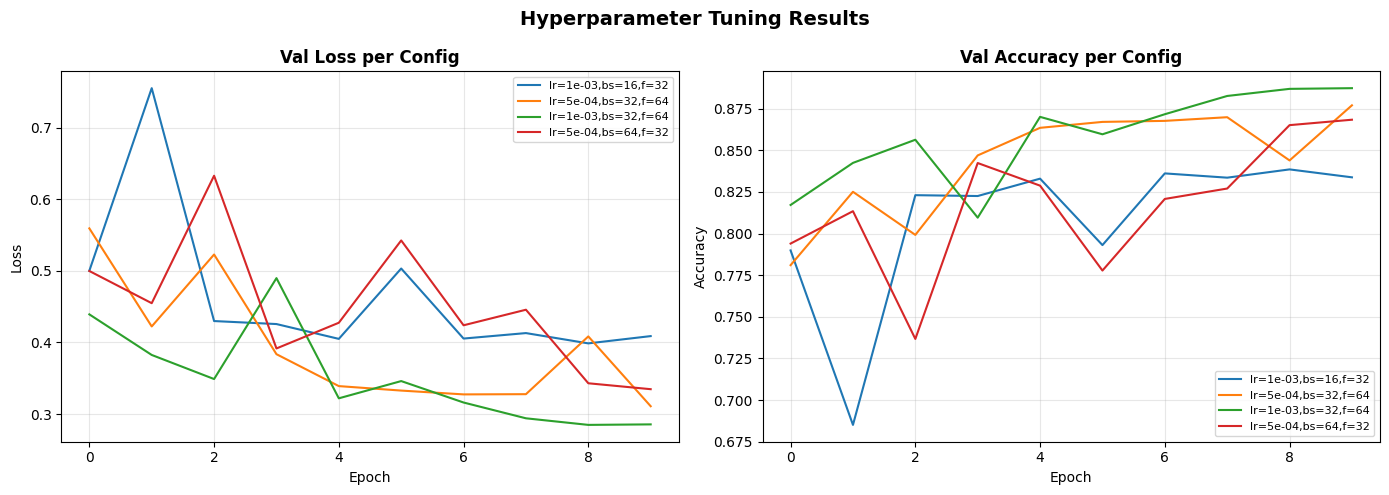

In [34]:
# Display hyperparameter tuning results
print("\n" + "="*70)
print("HYPERPARAMETER TUNING RESULTS")
print("="*70)
print(f"{'Config':>8} {'LR':>8} {'BS':>4} {'WD':>8} {'Filters':>8} {'Val Acc':>8} {'Val Loss':>9}")
print("-"*70)

best_idx = np.argmax([r['best_val_acc'] for r in hp_results])
for i, r in enumerate(hp_results):
    marker = " <<< BEST" if i == best_idx else ""
    print(f"{i+1:>8} {r['lr']:>8.0e} {r['batch_size']:>4} {r['weight_decay']:>8.0e} "
          f"{r['base_filters']:>8} {r['best_val_acc']:>8.4f} {r['best_val_loss']:>9.4f}{marker}")

best_cfg = hp_results[best_idx]
print(f"\nBest config: lr={best_cfg['lr']}, bs={best_cfg['batch_size']}, "
      f"wd={best_cfg['weight_decay']}, filters={best_cfg['base_filters']}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, r in enumerate(hp_results):
    label = f"lr={r['lr']:.0e},bs={r['batch_size']},f={r['base_filters']}"
    axes[0].plot(r['history']['val_loss'], label=label, linewidth=1.5)
    axes[1].plot(r['history']['val_acc'], label=label, linewidth=1.5)

axes[0].set_title('Val Loss per Config', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Val Accuracy per Config', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('Hyperparameter Tuning Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hp_tuning.png'), dpi=150)
plt.show()

## 10. Retrain Best Model with Full Epochs

In [35]:
# Retrain with best hyperparameters
print(f"Retraining with best config for {EPOCHS} epochs...")

best_model = UNet(in_channels=7, num_classes=num_classes,
                  base_filters=best_cfg['base_filters']).to(device)

best_train_loader = DataLoader(train_ds, batch_size=best_cfg['batch_size'],
                               shuffle=True, num_workers=0)
best_val_loader = DataLoader(val_ds, batch_size=best_cfg['batch_size'],
                              shuffle=False, num_workers=0)

best_history = train_model(best_model, best_train_loader, best_val_loader,
                           epochs=EPOCHS, lr=best_cfg['lr'],
                           weight_decay=best_cfg['weight_decay'])

# Load best checkpoint
best_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_unet.pth'),
                                       map_location=device, weights_only=True))
print(f"\nBest model loaded. Final val acc: {max(best_history['val_acc']):.4f}")

Retraining with best config for 25 epochs...
  Epoch   1/25 | Train Loss: 0.5197 | Val Loss: 0.4841 | Val Acc: 0.8057
  Epoch   2/25 | Train Loss: 0.4160 | Val Loss: 0.3807 | Val Acc: 0.8453
  Epoch   4/25 | Train Loss: 0.3547 | Val Loss: 0.3368 | Val Acc: 0.8649
  Epoch   6/25 | Train Loss: 0.3190 | Val Loss: 0.3504 | Val Acc: 0.8581
  Epoch   8/25 | Train Loss: 0.2959 | Val Loss: 0.2901 | Val Acc: 0.8848
  Epoch  10/25 | Train Loss: 0.2794 | Val Loss: 0.2941 | Val Acc: 0.8837
  Epoch  12/25 | Train Loss: 0.2682 | Val Loss: 0.2980 | Val Acc: 0.8822
  Epoch  14/25 | Train Loss: 0.2602 | Val Loss: 0.2553 | Val Acc: 0.8991
  Epoch  16/25 | Train Loss: 0.2534 | Val Loss: 0.2634 | Val Acc: 0.8967
  Epoch  18/25 | Train Loss: 0.2485 | Val Loss: 0.2538 | Val Acc: 0.9017
  Epoch  20/25 | Train Loss: 0.2166 | Val Loss: 0.2217 | Val Acc: 0.9135
  Epoch  22/25 | Train Loss: 0.2051 | Val Loss: 0.2165 | Val Acc: 0.9160
  Epoch  24/25 | Train Loss: 0.2009 | Val Loss: 0.2029 | Val Acc: 0.9210

Best 

## 11. (c) Prediction & Evaluation on Test Set

In [3]:
# Predict on test set
best_model.eval()
all_preds = []
all_labels = []
all_inputs = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = best_model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.append(pred)
        all_labels.append(Y_batch.numpy())
        all_inputs.append(X_batch.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_inputs = np.concatenate(all_inputs)

# Compute test accuracy
mask = all_labels != 255
test_acc = np.mean(all_preds[mask] == all_labels[mask])
print(f"Test Accuracy: {test_acc:.4f}")

# Per-class accuracy
print("\nPer-class accuracy:")
for i in range(num_classes):
    cls_mask = all_labels == i
    if cls_mask.sum() > 0:
        cls_acc = np.mean(all_preds[cls_mask] == i)
        orig = idx_to_class[i]
        print(f"  {LULC_INFO[orig][0]:20s}: {cls_acc:.4f} ({cls_mask.sum():>8,} px)")

Test Accuracy: 0.9213

Per-class accuracy:
  Water               : 0.8958 ( 396,915 px)
  Trees               : 0.8875 (13,295,591 px)
  Flooded Veg.        : 0.0000 (   1,433 px)
  Crops               : 0.9447 (19,555,581 px)
  Built Area          : 0.9107 (4,915,814 px)
  Bare Ground         : 0.3349 (  99,898 px)
  Snow/Ice            : 0.0000 (     140 px)
  Clouds              : 0.0000 (      34 px)
  Rangeland           : 0.9253 (28,114,590 px)


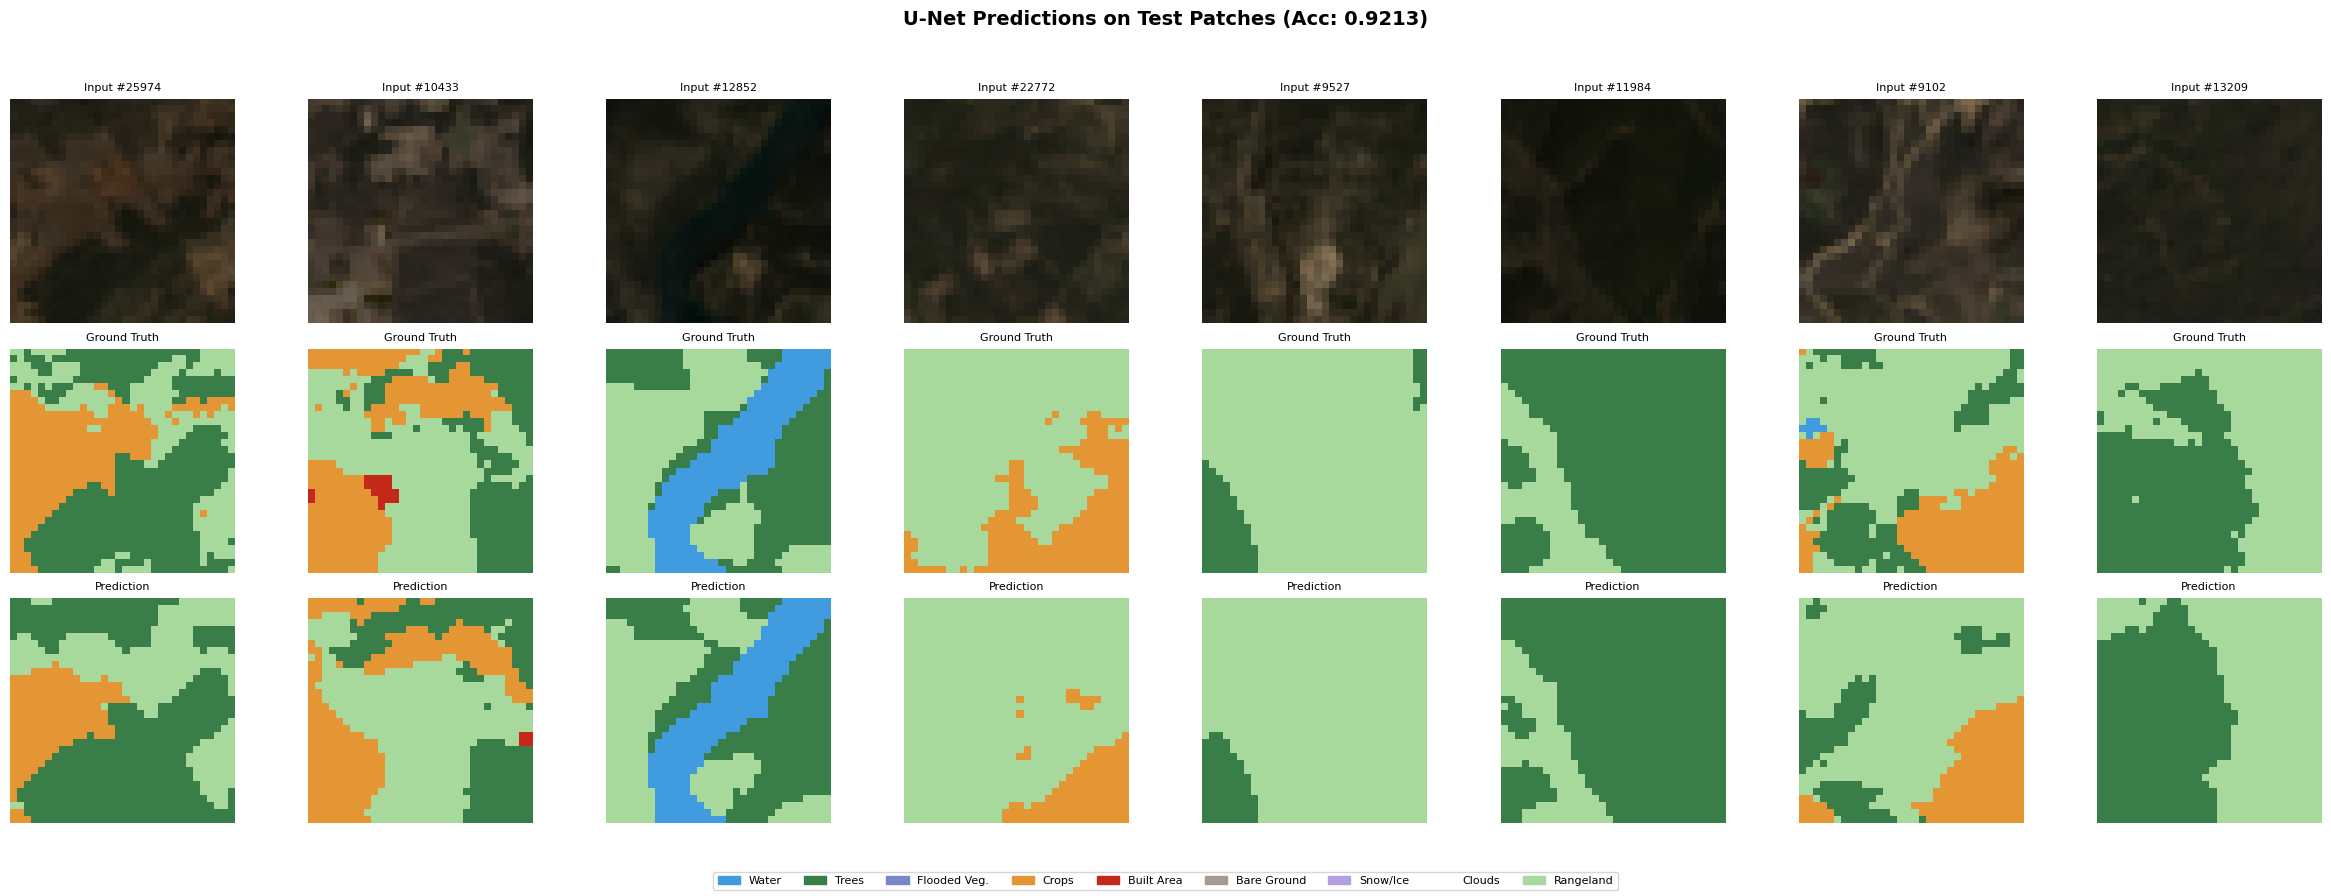

In [37]:
# Visualize sample predictions
colors_remap = [LULC_INFO[idx_to_class[i]][1] for i in range(num_classes)]
cmap_pred = mcolors.ListedColormap(colors_remap)
norm_pred = mcolors.BoundaryNorm(range(num_classes + 1), cmap_pred.N)

# Show 8 random test patches
fig, axes = plt.subplots(3, 8, figsize=(24, 9))
sample_ids = np.random.choice(len(all_preds), 8, replace=False)

for col, idx in enumerate(sample_ids):
    # Row 0: Input RGB
    patch_rgb = all_inputs[idx][[2,1,0]].transpose(1,2,0)  # B4,B3,B2
    patch_rgb = np.clip(np.power(patch_rgb, 1/1.4), 0, 1)
    axes[0, col].imshow(patch_rgb)
    axes[0, col].set_title(f'Input #{idx}', fontsize=8)
    axes[0, col].axis('off')
    
    # Row 1: Ground truth
    gt = all_labels[idx].copy()
    gt[gt == 255] = 0  # display ignore as first class
    axes[1, col].imshow(gt, cmap=cmap_pred, norm=norm_pred, interpolation='nearest')
    axes[1, col].set_title('Ground Truth', fontsize=8)
    axes[1, col].axis('off')
    
    # Row 2: Prediction
    axes[2, col].imshow(all_preds[idx], cmap=cmap_pred, norm=norm_pred, interpolation='nearest')
    axes[2, col].set_title('Prediction', fontsize=8)
    axes[2, col].axis('off')

# Add legend
legend_patches = [mpatches.Patch(color=LULC_INFO[idx_to_class[i]][1],
                  label=LULC_INFO[idx_to_class[i]][0])
                  for i in range(num_classes)]
fig.legend(handles=legend_patches, loc='lower center', ncol=num_classes, fontsize=8)

plt.suptitle(f'U-Net Predictions on Test Patches (Acc: {test_acc:.4f})',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig(os.path.join(OUTPUT_DIR, 'predictions.png'), dpi=150)
plt.show()

In [38]:
# Final summary
print("="*60)
print("TASK 4 SUMMARY")
print("="*60)
print(f"  Architecture  : U-Net (3-level encoder-decoder + skip connections)")
print(f"  Input         : 7 channels (Landsat B2-B7 + NDVI), 32x32 patches")
print(f"  Output        : {num_classes} LULC classes")
print(f"  Patch size    : {PATCH_SIZE}x{PATCH_SIZE}, stride {STRIDE}")
print(f"  Total patches : {len(valid_coords)}")
print(f"  Train/Val/Test: {len(train_coords)}/{len(val_coords)}/{len(test_coords)}")
print(f"  Best config   : lr={best_cfg['lr']}, bs={best_cfg['batch_size']}, "
      f"wd={best_cfg['weight_decay']}, filters={best_cfg['base_filters']}")
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Model saved   : {os.path.join(OUTPUT_DIR, 'best_unet.pth')}")
print("="*60)

TASK 4 SUMMARY
  Architecture  : U-Net (3-level encoder-decoder + skip connections)
  Input         : 7 channels (Landsat B2-B7 + NDVI), 32x32 patches
  Output        : 9 LULC classes
  Patch size    : 32x32, stride 8
  Total patches : 432233
  Train/Val/Test: 302563/64835/64835
  Best config   : lr=0.001, bs=32, wd=1e-05, filters=64
  Test Accuracy : 0.9213
  Model saved   : /teamspace/studios/this_studio/Antigravity/landsat_downloads/best_unet.pth


In [2]:
## ============================================================
## RECOVERY CELL — Run this after a kernel restart on Lightning AI
## Restores all variables without retraining the model.
## ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── 1. Paths — update BASE_DIR if needed ─────────────────────
BASE_DIR    = "/teamspace/studios/this_studio/Antigravity/landsat_downloads"
EXTRACT_DIR = os.path.join(BASE_DIR, "extracted")
OUTPUT_DIR  = BASE_DIR
LULC_FILE   = os.path.join(OUTPUT_DIR, "esri_lulc_clipped.tif")
MODEL_PATH  = os.path.join(OUTPUT_DIR, "best_unet.pth")

assert os.path.exists(MODEL_PATH),  f"Model not found: {MODEL_PATH}"
assert os.path.exists(LULC_FILE),   f"LULC file not found: {LULC_FILE}"
print("Paths OK")

# ── 2. LULC class map ────────────────────────────────────────
LULC_INFO = {
    0:  ("No Data",      "#000000"),
    1:  ("Water",        "#419BDF"),
    2:  ("Trees",        "#397D49"),
    4:  ("Flooded Veg.", "#7A87C6"),
    5:  ("Crops",        "#E49635"),
    7:  ("Built Area",   "#C4281B"),
    8:  ("Bare Ground",  "#A59B8F"),
    9:  ("Snow/Ice",     "#B39FE1"),
    10: ("Clouds",       "#FFFFFF"),
    11: ("Rangeland",    "#A8D99C"),
}

# ── 3. Load Landsat bands ─────────────────────────────────────
tif_files  = list(Path(EXTRACT_DIR).glob("*.[Tt][Ii][Ff]"))
band_paths = {}
for f in tif_files:
    for b in ['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']:
        if b in f.name.upper():
            band_paths[b] = str(f)

band_list  = ['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']
bands_data = []
for b in band_list:
    with rasterio.open(band_paths[b]) as src:
        data = src.read(1).astype(np.float32)
        if b == 'SR_B2':
            landsat_transform = src.transform
            landsat_crs       = src.crs
            H, W              = data.shape
        bands_data.append(data)

for i in range(len(bands_data)):
    bands_data[i] = np.clip(bands_data[i] * 0.0000275 - 0.2, 0, 1)

nir, red = bands_data[3], bands_data[2]
denom    = nir + red
ndvi     = np.where(denom > 0, (nir - red) / denom, 0).astype(np.float32)
ndvi     = np.clip(ndvi, -1, 1)

image_stack = np.stack(bands_data + [ndvi], axis=0)   # (7, H, W)
del bands_data, nir, red, denom, ndvi
print(f"Image stack: {image_stack.shape}")

# ── 4. Load & remap LULC ─────────────────────────────────────
with rasterio.open(LULC_FILE) as src:
    lulc_10m       = src.read(1)
    lulc_transform = src.transform
    lulc_crs       = src.crs

lulc_30m = np.zeros((H, W), dtype=np.uint8)
reproject(source=lulc_10m, destination=lulc_30m,
          src_transform=lulc_transform, src_crs=lulc_crs,
          dst_transform=landsat_transform, dst_crs=landsat_crs,
          resampling=Resampling.nearest)
del lulc_10m

raw_classes  = sorted(np.unique(lulc_30m))
train_classes = [c for c in raw_classes if c != 0]
class_to_idx  = {c: i for i, c in enumerate(train_classes)}
idx_to_class  = {i: c for c, i in class_to_idx.items()}
num_classes   = len(train_classes)

lulc_remapped = np.full_like(lulc_30m, fill_value=255, dtype=np.uint8)
for c, idx in class_to_idx.items():
    lulc_remapped[lulc_30m == c] = idx
del lulc_30m
print(f"Classes ({num_classes}): {[LULC_INFO[c][0] for c in train_classes]}")

# ── 5. Rebuild patch coords & test split ─────────────────────
PATCH_SIZE = 32
STRIDE     = 8

valid_coords = []
from tqdm import tqdm
for r in tqdm(range(0, H - PATCH_SIZE + 1, STRIDE), desc="Scanning patches"):
    for c in range(0, W - PATCH_SIZE + 1, STRIDE):
        lp = lulc_remapped[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        if np.mean(lp == 255) > 0.2:
            continue
        if np.mean(image_stack[0, r:r+PATCH_SIZE, c:c+PATCH_SIZE] == 0) > 0.2:
            continue
        valid_coords.append((r, c))

valid_coords = np.array(valid_coords, dtype=np.int32)
print(f"Valid patches: {len(valid_coords)}")

indices  = np.arange(len(valid_coords))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, random_state=42)
test_coords = valid_coords[test_idx]

# ── 6. Dataset & DataLoader ──────────────────────────────────
class LazyPatchDataset(Dataset):
    def __init__(self, image_stack, label_array, coords, patch_size=32):
        self.image  = image_stack
        self.labels = label_array
        self.coords = coords
        self.ps     = patch_size
    def __len__(self):
        return len(self.coords)
    def __getitem__(self, idx):
        r, c = self.coords[idx]
        x = self.image[:, r:r+self.ps, c:c+self.ps].copy()
        y = self.labels[r:r+self.ps, c:c+self.ps].copy()
        return torch.from_numpy(x), torch.from_numpy(y).long()

test_ds     = LazyPatchDataset(image_stack, lulc_remapped, test_coords, PATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
print(f"Test patches: {len(test_ds)}")

# ── 7. Rebuild model & load weights ──────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),   # bias=True (default)
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),   # bias=True (default)
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=7, num_classes=6, base_filters=32):
        super().__init__()
        f = base_filters
        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f,   f*2)
        self.enc3 = ConvBlock(f*2, f*4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(f*4, f*8)
        self.up3  = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
        self.dec3 = ConvBlock(f*8, f*4)
        self.up2  = nn.ConvTranspose2d(f*4, f*2, 2, stride=2)
        self.dec2 = ConvBlock(f*4, f*2)
        self.up1  = nn.ConvTranspose2d(f*2, f,   2, stride=2)
        self.dec1 = ConvBlock(f*2, f)
        self.out_conv = nn.Conv2d(f, num_classes, 1)   # must match saved name
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)

# Use the best config found during HP tuning — update base_filters if different
best_model = UNet(in_channels=7, num_classes=num_classes, base_filters=64).to(device)
best_model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device, weights_only=True)
)
best_model.eval()
print(f"Model loaded from {MODEL_PATH}")

# ── 8. Quick test accuracy check ─────────────────────────────
correct, total = 0, 0
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        pred = best_model(X_batch.to(device)).argmax(dim=1).cpu()
        m    = Y_batch != 255
        correct += (pred[m] == Y_batch[m]).sum().item()
        total   += m.sum().item()
print(f"\nTest Accuracy (sanity check): {correct/max(total,1):.4f}")
print("\n✓ All variables restored. You can now run the evaluation cells (12-B onwards).")

Device: cuda
Paths OK
Image stack: (7, 7911, 7791)
Classes (9): ['Water', 'Trees', 'Flooded Veg.', 'Crops', 'Built Area', 'Bare Ground', 'Snow/Ice', 'Clouds', 'Rangeland']


Scanning patches: 100%|██████████| 985/985 [00:07<00:00, 133.05it/s]


Valid patches: 432233
Test patches: 64835
Model loaded from /teamspace/studios/this_studio/Antigravity/landsat_downloads/best_unet.pth

Test Accuracy (sanity check): 0.9213

✓ All variables restored. You can now run the evaluation cells (12-B onwards).


In [5]:
# ── Restore class mappings ────────────────────────────────────
LULC_INFO = {
    1:  ("Water",        "#419BDF"),
    2:  ("Trees",        "#397D49"),
    4:  ("Flooded Veg.", "#7A87C6"),
    5:  ("Crops",        "#E49635"),
    7:  ("Built Area",   "#C4281B"),
    8:  ("Bare Ground",  "#A59B8F"),
    9:  ("Snow/Ice",     "#B39FE1"),
    10: ("Clouds",       "#FFFFFF"),
    11: ("Rangeland",    "#A8D99C"),
}

train_classes = [1, 2, 4, 5, 7, 8, 9, 10, 11]   # from your log
class_to_idx  = {c: i for i, c in enumerate(train_classes)}
idx_to_class  = {i: c for c, i in class_to_idx.items()}
num_classes   = len(train_classes)   # 9

class_names  = [LULC_INFO[idx_to_class[i]][0] for i in range(num_classes)]
class_colors = [LULC_INFO[idx_to_class[i]][1] for i in range(num_classes)]

OUTPUT_DIR = "/teamspace/studios/this_studio/Antigravity/landsat_downloads"

print(f"num_classes : {num_classes}")
print(f"class_names : {class_names}")

num_classes : 9
class_names : ['Water', 'Trees', 'Flooded Veg.', 'Crops', 'Built Area', 'Bare Ground', 'Snow/Ice', 'Clouds', 'Rangeland']


Valid pixels : 66,379,996
Classes      : ['Water', 'Trees', 'Flooded Veg.', 'Crops', 'Built Area', 'Bare Ground', 'Snow/Ice', 'Clouds', 'Rangeland']


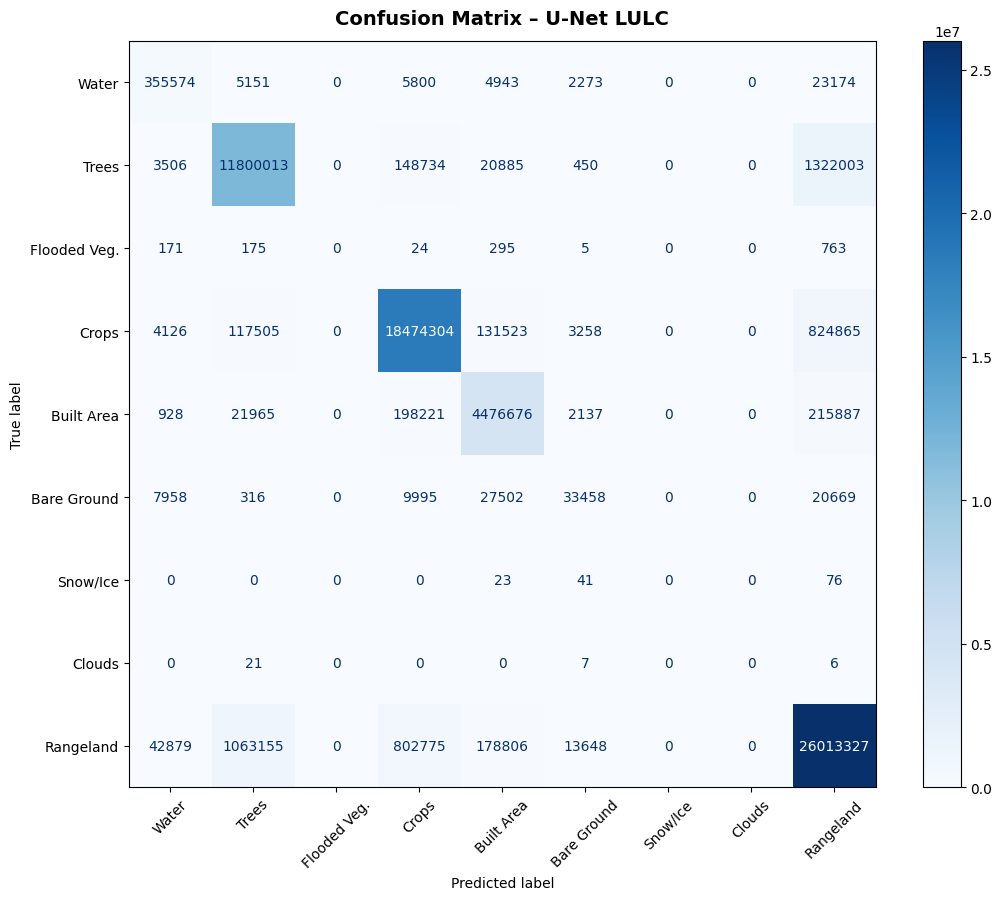

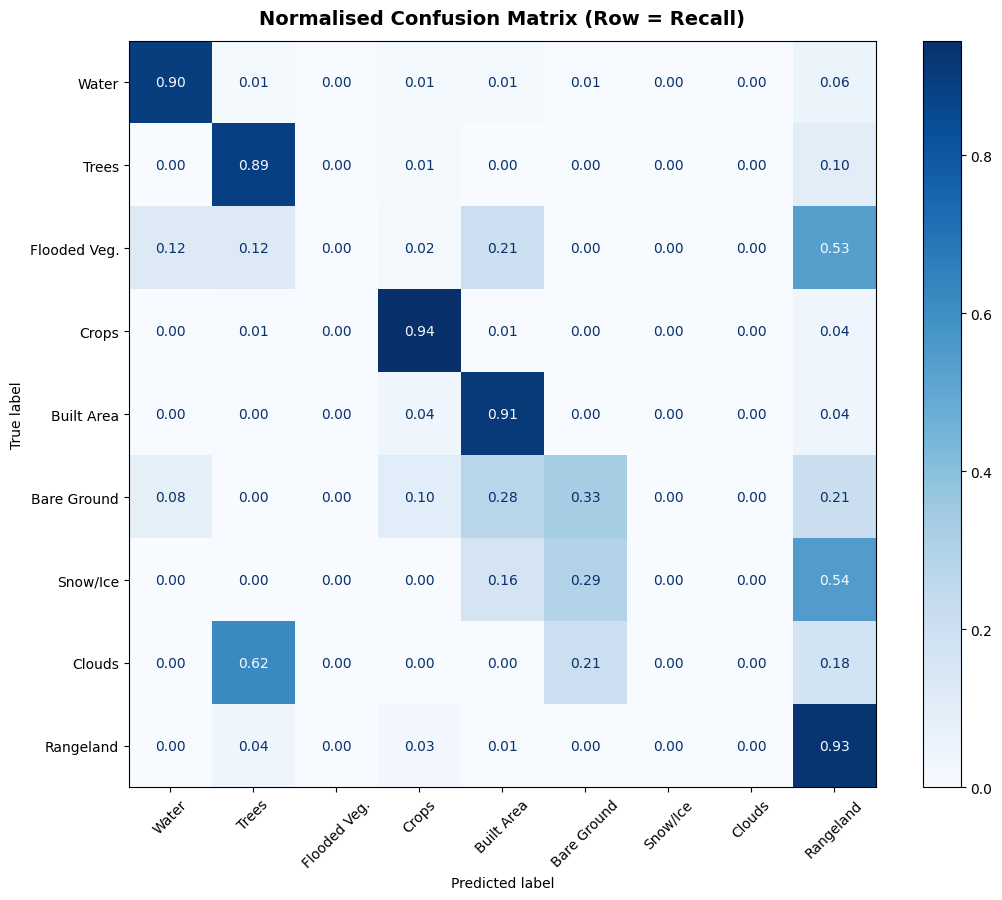

Saved: confusion_matrix.png  &  confusion_matrix_norm.png

Class                    F1        IoU
----------------------------------------
Water                0.8757     0.7789
Trees                0.8972     0.8136
Flooded Veg.         0.0000     0.0000
Crops                0.9427     0.8916
Built Area           0.9177     0.8479
Bare Ground          0.4312     0.2749
Snow/Ice             0.0000     0.0000
Clouds               0.0000     0.0000
Rangeland            0.9202     0.8523
Macro F1             0.5539
Weighted F1          0.9210
mIoU                 0.4955


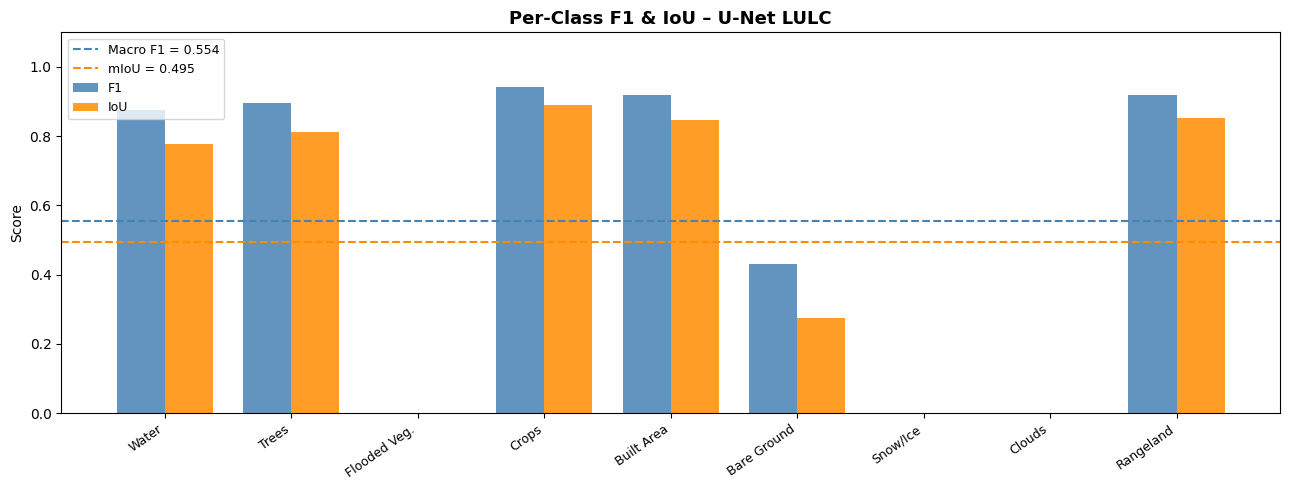

Saved: f1_iou_per_class.png


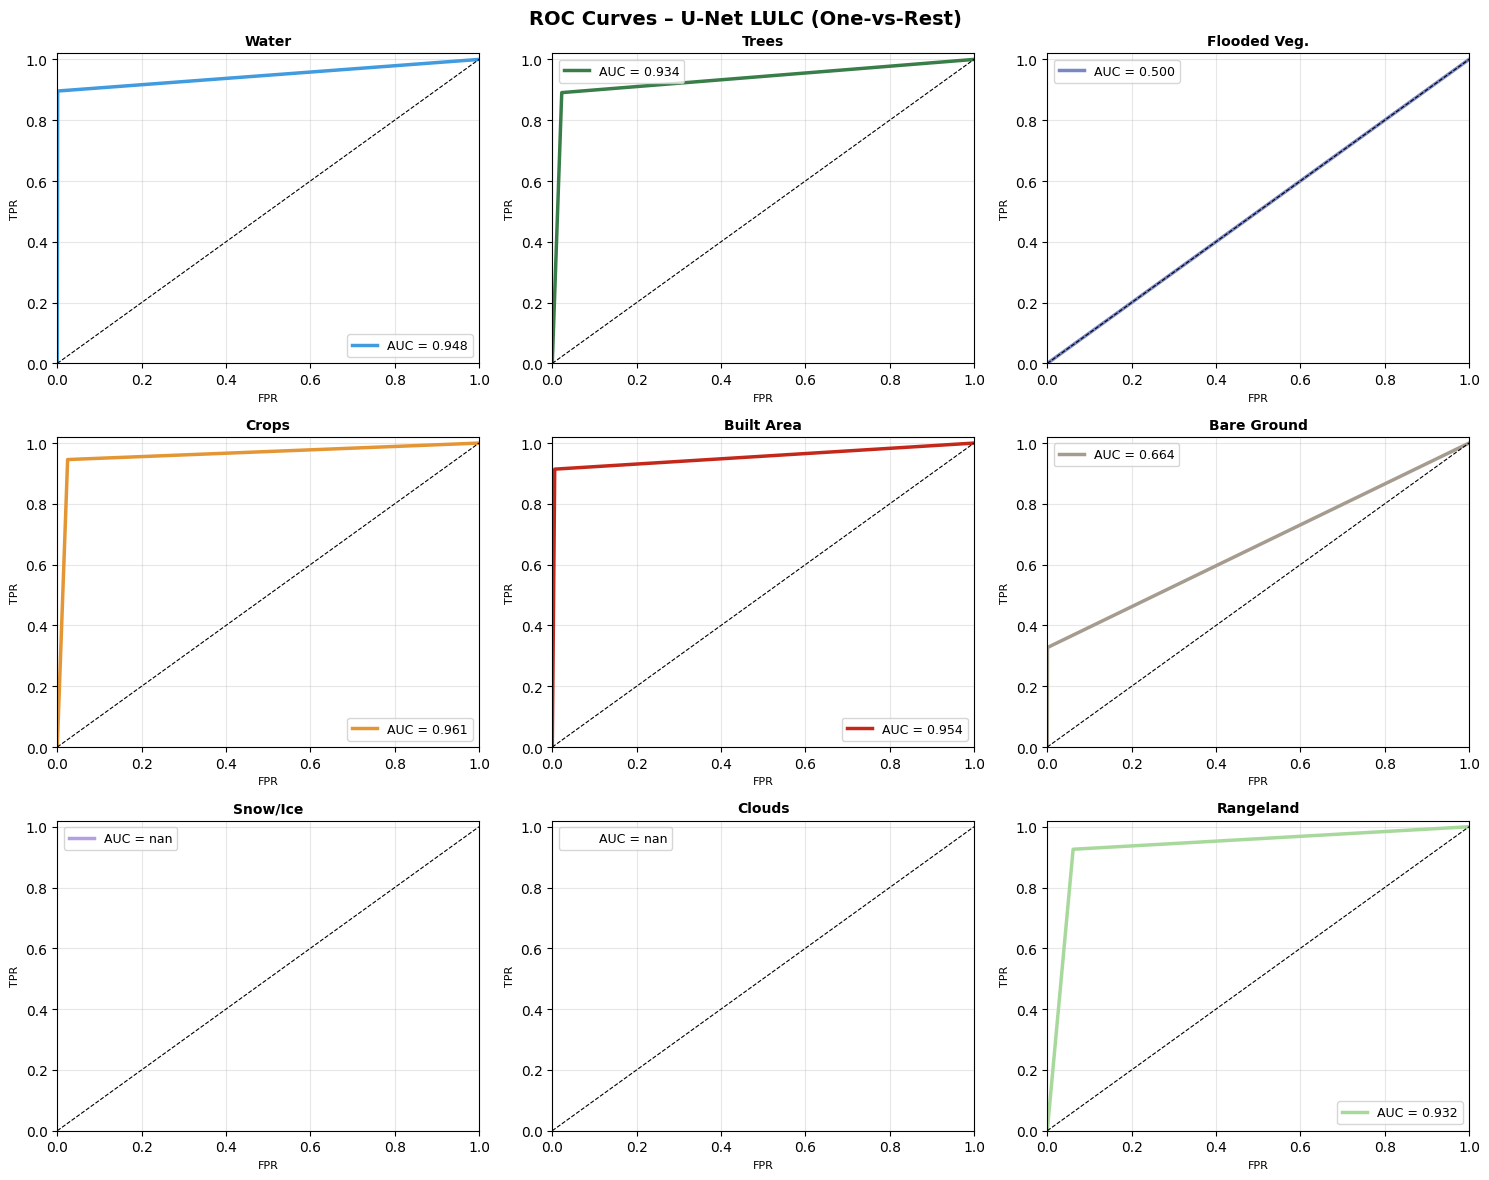

Saved: roc_curves.png

ROC AUC per class:
  Water              0.9476
  Trees              0.9342
  Flooded Veg.       0.5000
  Crops              0.9606
  Built Area         0.9542
  Bare Ground        0.6635
  Snow/Ice           nan
  Clouds             nan
  Rangeland          0.9323

  Macro AUC : nan

FINAL EVALUATION SUMMARY
  Overall Accuracy : 0.9213
  Macro F1         : 0.5539
  Weighted F1      : 0.9210
  Mean IoU (mIoU)  : 0.4955
  Macro ROC-AUC    : nan

All plots saved to: /teamspace/studios/this_studio/Antigravity/landsat_downloads


In [6]:
## ============================================================
## CELL 1 — Run inference on test set (collect preds + labels)
## ============================================================
import numpy as np
import torch

best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        pred = best_model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.append(pred)
        all_labels.append(Y_batch.numpy())

all_preds  = np.concatenate(all_preds)   # (N, 32, 32)
all_labels = np.concatenate(all_labels)  # (N, 32, 32)

# Flatten — ignore padded pixels (255)
mask   = all_labels != 255
y_true = all_labels[mask]
y_pred = all_preds[mask]

print(f"Valid pixels : {y_true.size:,}")
print(f"Classes      : {class_names}")


## ============================================================
## CELL 2 — Confusion Matrix
## ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

# Raw counts
fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d', xticks_rotation=45)
ax.set_title('Confusion Matrix – U-Net LULC', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Row-normalised  (= per-class recall on the diagonal)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig2, ax2 = plt.subplots(figsize=(11, 9))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp2.plot(ax=ax2, colorbar=True, cmap='Blues', values_format='.2f', xticks_rotation=45)
ax2.set_title('Normalised Confusion Matrix (Row = Recall)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_norm.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: confusion_matrix.png  &  confusion_matrix_norm.png")


## ============================================================
## CELL 3 — F1 & IoU (per class + macro/weighted)
## ============================================================
from sklearn.metrics import f1_score, jaccard_score

labels_list   = list(range(num_classes))
f1_per_class  = f1_score (y_true, y_pred, labels=labels_list, average=None, zero_division=0)
iou_per_class = jaccard_score(y_true, y_pred, labels=labels_list, average=None, zero_division=0)
f1_macro      = f1_score (y_true, y_pred, average='macro',    zero_division=0)
f1_weighted   = f1_score (y_true, y_pred, average='weighted', zero_division=0)
miou          = np.nanmean(iou_per_class)

# Print table
print(f"\n{'Class':<18} {'F1':>8} {'IoU':>10}")
print("-" * 40)
for i, name in enumerate(class_names):
    print(f"{name:<18} {f1_per_class[i]:>8.4f} {iou_per_class[i]:>10.4f}")
print("=" * 40)
print(f"{'Macro F1':<18} {f1_macro:>8.4f}")
print(f"{'Weighted F1':<18} {f1_weighted:>8.4f}")
print(f"{'mIoU':<18} {miou:>8.4f}")

# Bar chart
x     = np.arange(num_classes)
width = 0.38
fig3, ax3 = plt.subplots(figsize=(13, 5))
ax3.bar(x - width/2, f1_per_class,  width, label='F1',  color='steelblue',  alpha=0.85)
ax3.bar(x + width/2, iou_per_class, width, label='IoU', color='darkorange', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(class_names, rotation=35, ha='right', fontsize=9)
ax3.set_ylabel('Score'); ax3.set_ylim(0, 1.1)
ax3.axhline(f1_macro, color='steelblue',  linestyle='--', lw=1.5, label=f'Macro F1 = {f1_macro:.3f}')
ax3.axhline(miou,     color='darkorange', linestyle='--', lw=1.5, label=f'mIoU = {miou:.3f}')
ax3.legend(fontsize=9)
ax3.set_title('Per-Class F1 & IoU – U-Net LULC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/f1_iou_per_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f1_iou_per_class.png")


## ============================================================
## CELL 4 — ROC Curves (One-vs-Rest, per class)
## ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Cap at 500k pixels to keep RAM manageable
MAX_PIX = 500_000
if y_true.size > MAX_PIX:
    rng  = np.random.default_rng(42)
    idx  = rng.choice(y_true.size, MAX_PIX, replace=False)
    yt_r = y_true[idx];  yp_r = y_pred[idx]
else:
    yt_r, yp_r = y_true, y_pred

# One-hot as probability proxy (replace with softmax outputs for true AUC)
yp_soft = np.eye(num_classes, dtype=np.float32)[yp_r]   # (N, 9)
yt_bin  = label_binarize(yt_r, classes=list(range(num_classes)))

colors = [LULC_INFO[idx_to_class[i]][1] for i in range(num_classes)]

n_cols = 3
n_rows = int(np.ceil(num_classes / n_cols))   # 3 rows x 3 cols for 9 classes
fig4, axes4 = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes4 = axes4.flatten()

roc_aucs = {}
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(yt_bin[:, i], yp_soft[:, i])
    roc_auc     = auc(fpr, tpr)
    roc_aucs[name] = roc_auc
    ax = axes4[i]
    ax.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

for j in range(num_classes, len(axes4)):
    axes4[j].set_visible(False)

plt.suptitle('ROC Curves – U-Net LULC (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

print("\nROC AUC per class:")
for name, val in roc_aucs.items():
    print(f"  {name:<18} {val:.4f}")
macro_auc = np.mean(list(roc_aucs.values()))
print(f"\n  Macro AUC : {macro_auc:.4f}")


## ============================================================
## CELL 5 — Final Summary
## ============================================================
print("\n" + "=" * 55)
print("FINAL EVALUATION SUMMARY")
print("=" * 55)
print(f"  Overall Accuracy : {np.mean(y_pred == y_true):.4f}")
print(f"  Macro F1         : {f1_macro:.4f}")
print(f"  Weighted F1      : {f1_weighted:.4f}")
print(f"  Mean IoU (mIoU)  : {miou:.4f}")
print(f"  Macro ROC-AUC    : {macro_auc:.4f}")
print("=" * 55)
print(f"\nAll plots saved to: {OUTPUT_DIR}")